In [3]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import pygmt

# Grow the GPU memory usage as needed
gpus = tf.config.experimental.list_physical_devices("GPU")
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices("GPU")
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

import nn_gmm
from qcore.uncertainties import mag_scaling
from qcore import constants

1 Physical GPUs, 1 Logical GPUs


## Source Parameters

- Magnitude
- Z_TOR
- H_DEPTH
- Dip
- Rake
- Width

In [4]:
# Data config
source_params_dir = Path("/home/claudy/dev/work/data/nn_gmm/input_data/source_rel_params")
site_params_dir = Path("/home/claudy/dev/work/data/nn_gmm/input_data/site_params")

distance_dir = Path("/home/claudy/dev/work/data/nn_gmm/input_data/distance_data")

In [5]:
# Load source params
rel_df = nn_gmm.load_dfs(
    list(source_params_dir.glob("*.csv")), index_col="realisation"
)

# Load site data
site_df = nn_gmm.load_dfs(list(site_params_dir.glob("*.csv")))

# Check & Drop duplicates
n_unique_stations = np.unique(site_df.station.values.astype(str)).shape[0]
site_df = site_df.drop_duplicates()
assert n_unique_stations == site_df.shape[0]
site_df.set_index("station", inplace=True)
site_df.drop_duplicates(subset={"lat", "lon"}, inplace=True)

# Load distance data
distance_db_ffps = list(distance_dir.glob("*.db"))
distance_df = nn_gmm.load_distance_df(site_df, distance_db_ffps, n_procs=12)


In [18]:
# Config
mag = 8.0
rake = 0.0
dip = 90

length, width = mag_scaling.mw_to_lw_scaling_relation(mag, mag_scaling.MagnitudeScalingRelations.SKARLATOUDIS2016, rake=rake)


print(f"Estimated fault width for mag {mag}: {width}")

Estimated fault width for mag 8.0: 137.71670814649053


Text(0.5, 0, 'Magnitude')

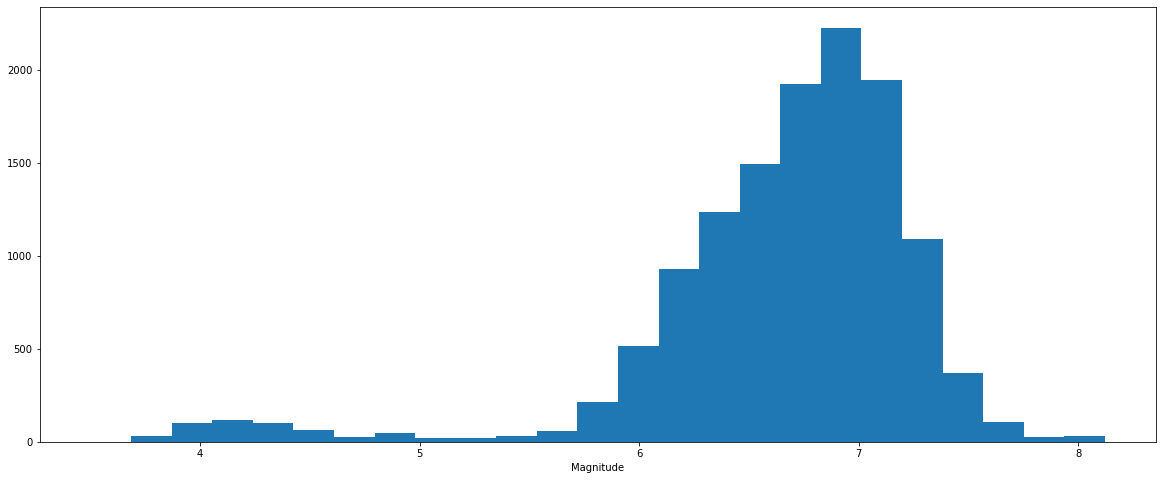

In [19]:
fig = plt.figure(figsize=(20, 8))

plt.hist(rel_df.mag, bins=25)
plt.xlabel("Magnitude")

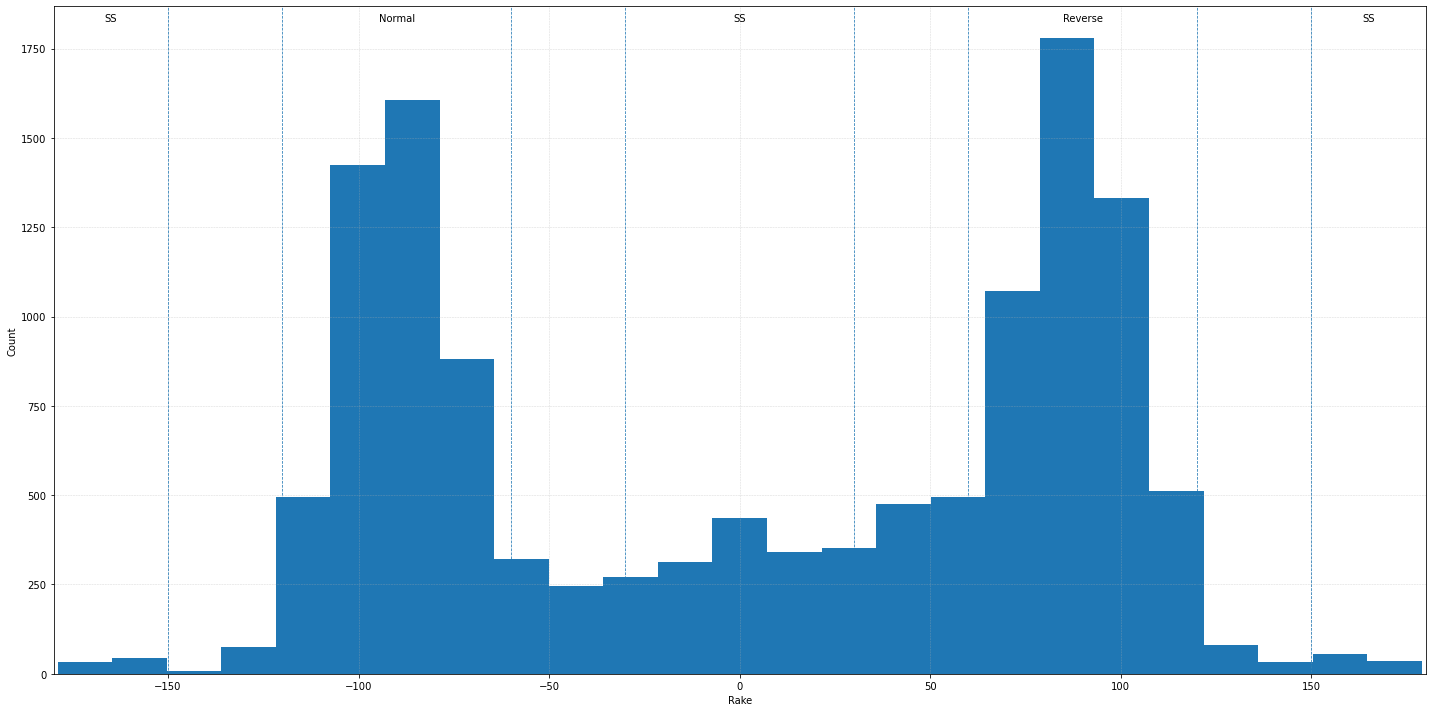

In [20]:
fig = plt.figure(figsize=(20, 10))

ax = fig.add_subplot(1, 1, 1)

ax.hist(rel_df.rake, bins=25)

# Normal
ax.axvline(-120, linestyle="--", linewidth=0.75)
ax.axvline(-60, linestyle="--", linewidth=0.75)
ax.text(-90, ax.get_ylim()[1] - 20, f"Normal", horizontalalignment="center", verticalalignment="top")


# Strike Slip
ax.axvline(-30, linestyle="--", linewidth=0.75)
ax.axvline(30, linestyle="--", linewidth=0.75)
ax.text(0, ax.get_ylim()[1] - 20, f"SS", horizontalalignment="center", verticalalignment="top")

# Reverse
ax.axvline(120, linestyle="--", linewidth=0.75)
ax.axvline(60, linestyle="--", linewidth=0.75)
ax.text(90, ax.get_ylim()[1] - 20, f"Reverse", horizontalalignment="center", verticalalignment="top")

# Strike Slip
ax.axvline(150, linestyle="--", linewidth=0.75)
ax.axvline(-150, linestyle="--", linewidth=0.75)
ax.text(165, ax.get_ylim()[1] - 20, f"SS", horizontalalignment="center", verticalalignment="top")
ax.text(-165, ax.get_ylim()[1] - 20, f"SS", horizontalalignment="center", verticalalignment="top")


ax.set_xlim(-180, 180)



plt.xlabel(f"Rake")
plt.ylabel(f"Count")
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
plt.tight_layout()

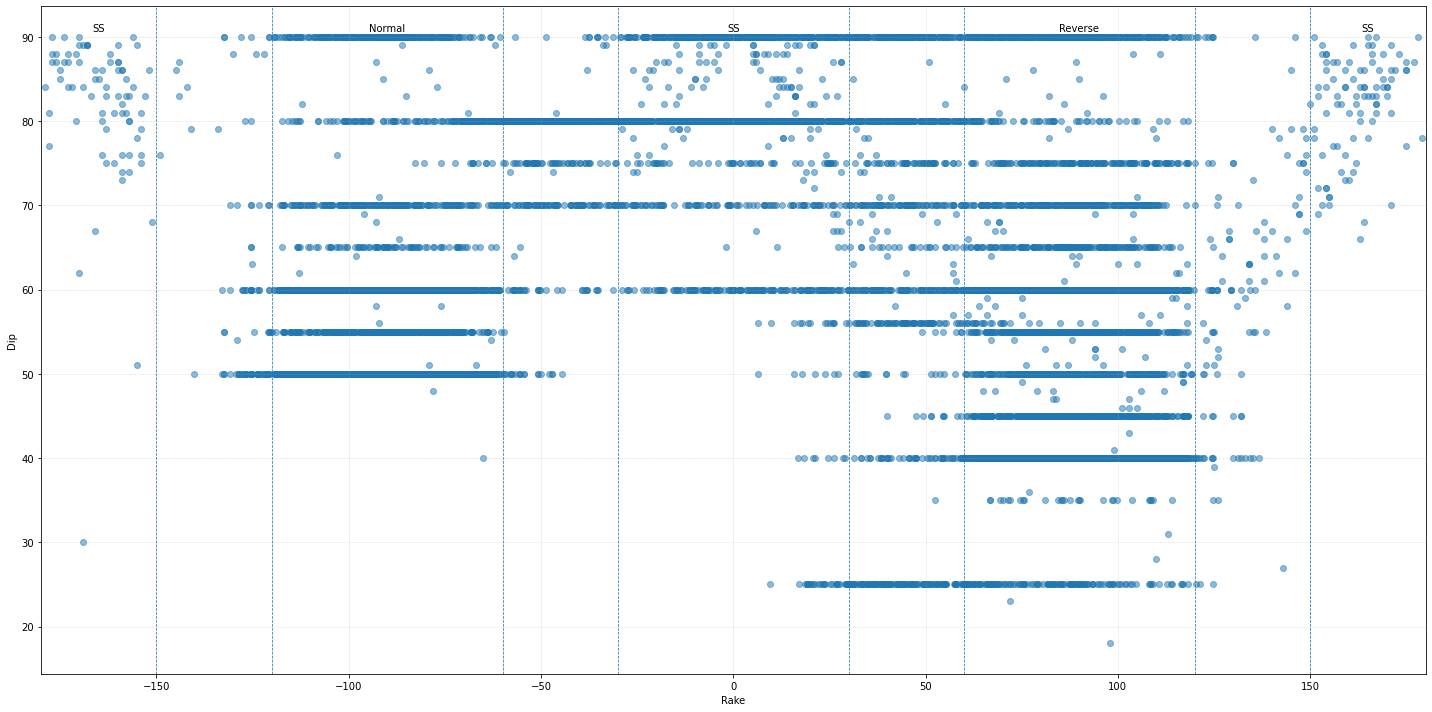

In [21]:
fig = plt.figure(figsize=(20, 10))

ax = fig.add_subplot(1, 1, 1)

ax.scatter(rel_df.rake, rel_df.dip, alpha=0.5)

# Normal
ax.axvline(-120, linestyle="--", linewidth=0.75)
ax.axvline(-60, linestyle="--", linewidth=0.75)
ax.text(-90, ax.get_ylim()[1] - 2, f"Normal", horizontalalignment="center", verticalalignment="top")


# Strike Slip
ax.axvline(-30, linestyle="--", linewidth=0.75)
ax.axvline(30, linestyle="--", linewidth=0.75)
ax.text(0, ax.get_ylim()[1] - 2, f"SS", horizontalalignment="center", verticalalignment="top")

# Reverse
ax.axvline(120, linestyle="--", linewidth=0.75)
ax.axvline(60, linestyle="--", linewidth=0.75)
ax.text(90, ax.get_ylim()[1] - 2, f"Reverse", horizontalalignment="center", verticalalignment="top")

# Strike Slip
ax.axvline(150, linestyle="--", linewidth=0.75)
ax.axvline(-150, linestyle="--", linewidth=0.75)
ax.text(165, ax.get_ylim()[1] - 2, f"SS", horizontalalignment="center", verticalalignment="top")
ax.text(-165, ax.get_ylim()[1] - 2, f"SS", horizontalalignment="center", verticalalignment="top")


ax.set_xlim(-180, 180)

ax.set_xlabel(f"Rake")
ax.set_ylabel(f"Dip")
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")

fig.tight_layout()


9380 dip slip ruptures


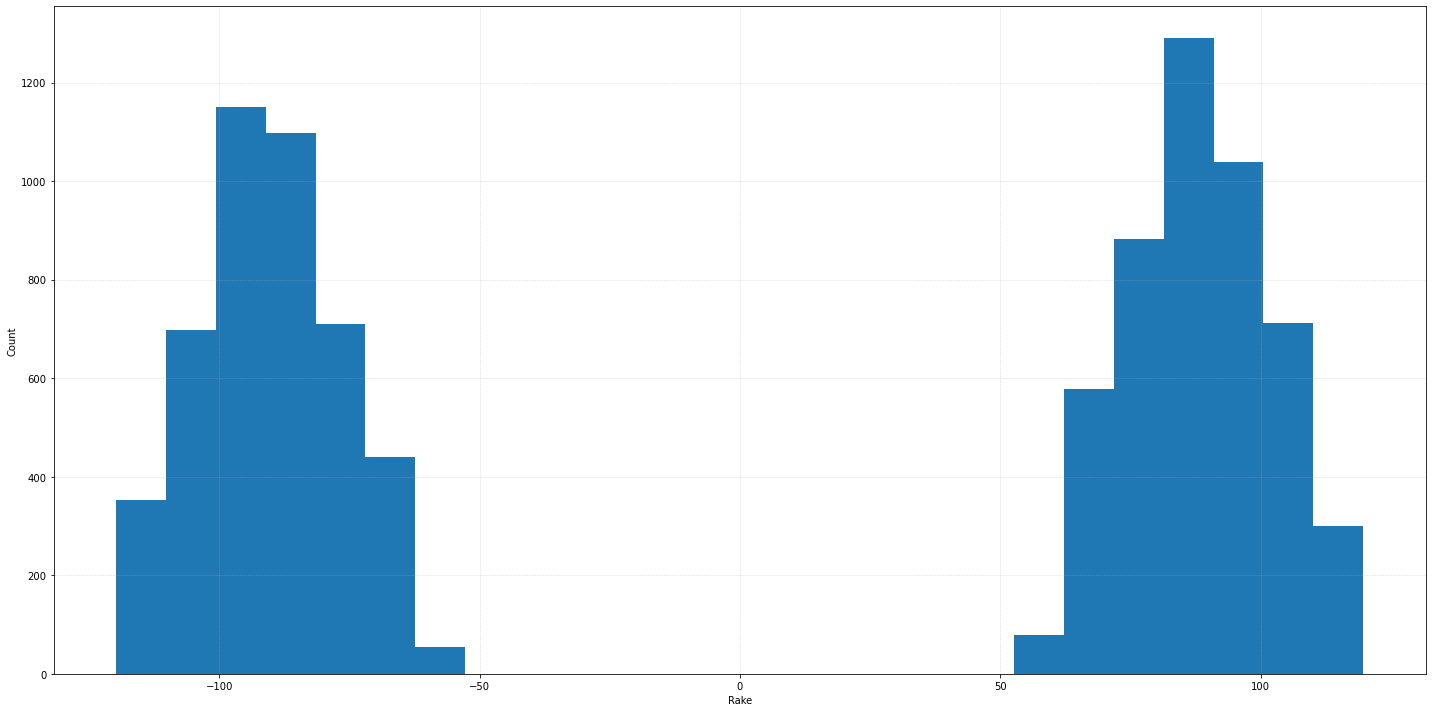

In [22]:
# Dip-Slip
dip_slip_mask = ((rel_df.rake > -120) & (rel_df.rake < -60)) | ((rel_df.rake > 60) & (rel_df.rake < 120))

fig = plt.figure(figsize=(20, 10))

plt.hist(rel_df.loc[dip_slip_mask].rake, bins=25)

plt.xlabel(f"Rake")
plt.ylabel(f"Count")
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
plt.tight_layout()

print(f"{np.count_nonzero(dip_slip_mask)} dip slip ruptures")

1646 strike slip ruptures


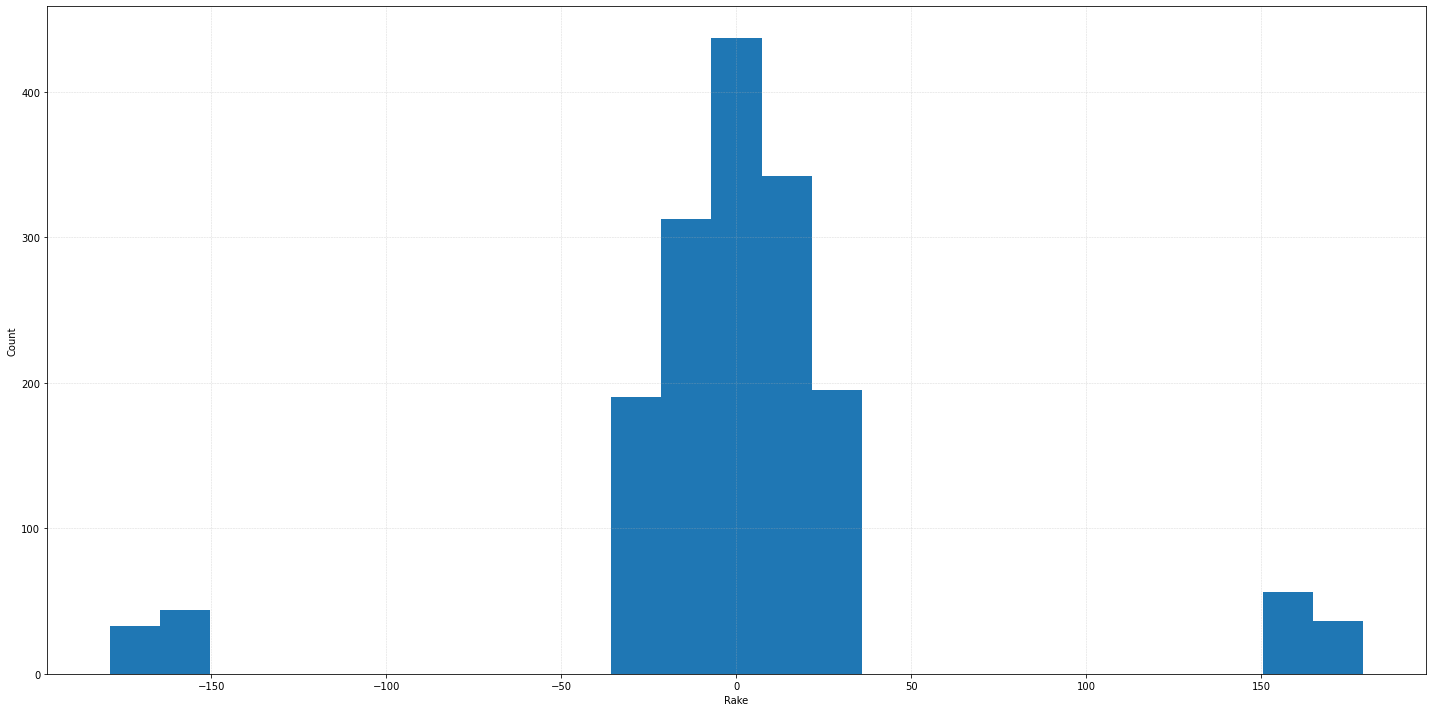

In [23]:
# Strike-Slip
strike_slip_mask = (rel_df.rake < -150) | (rel_df.rake > 150) | ((rel_df.rake > -30) & (rel_df.rake < 30))

fig = plt.figure(figsize=(20, 10))

plt.hist(rel_df.loc[strike_slip_mask].rake, bins=25)

plt.xlabel(f"Rake")
plt.ylabel(f"Count")
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
plt.tight_layout()

print(f"{np.count_nonzero(strike_slip_mask)} strike slip ruptures")

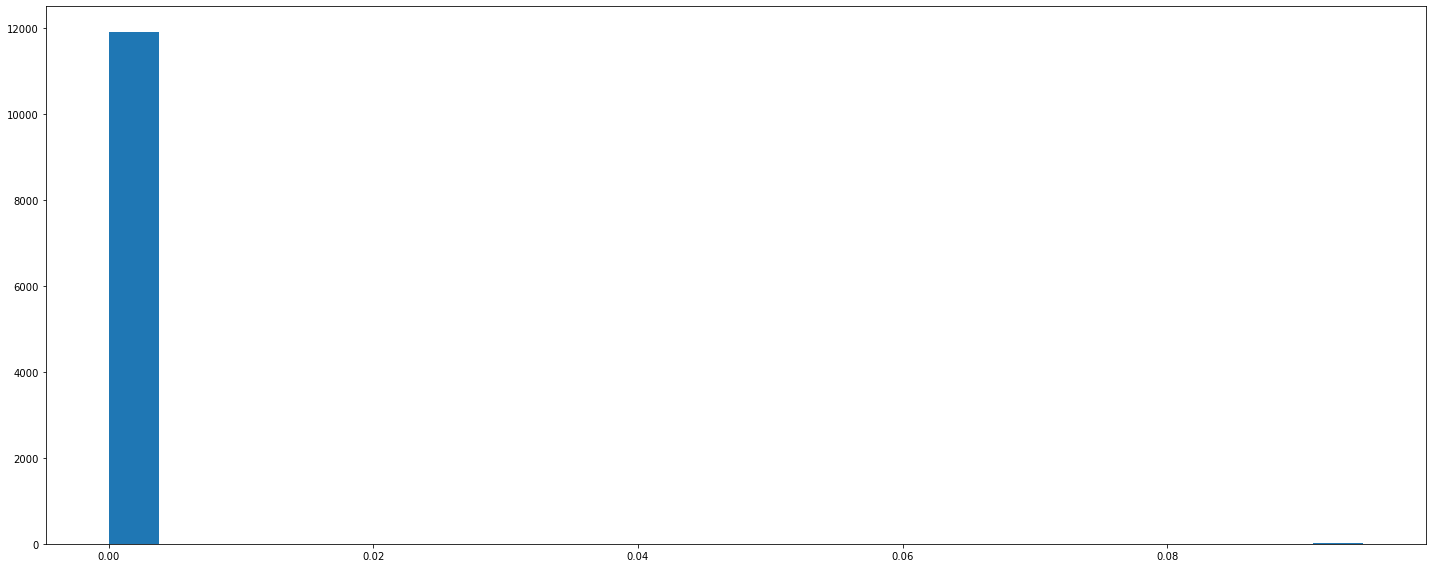

In [24]:
# ZTor
fig = plt.figure(figsize=(20, 8))

plt.hist(rel_df.loc[rel_df.ztor < 0.5, "ztor"], bins=25);

# t = rel_df.loc[:, ["mag", "ztor"]].drop_duplicates()
# plt.scatter(t.mag, t.ztor)
# plt.axvline(mag, c="k", linestyle="--")
# plt.xlabel("Mag")
# plt.ylabel("Ztor")

fig.tight_layout()

ztor = 0.0

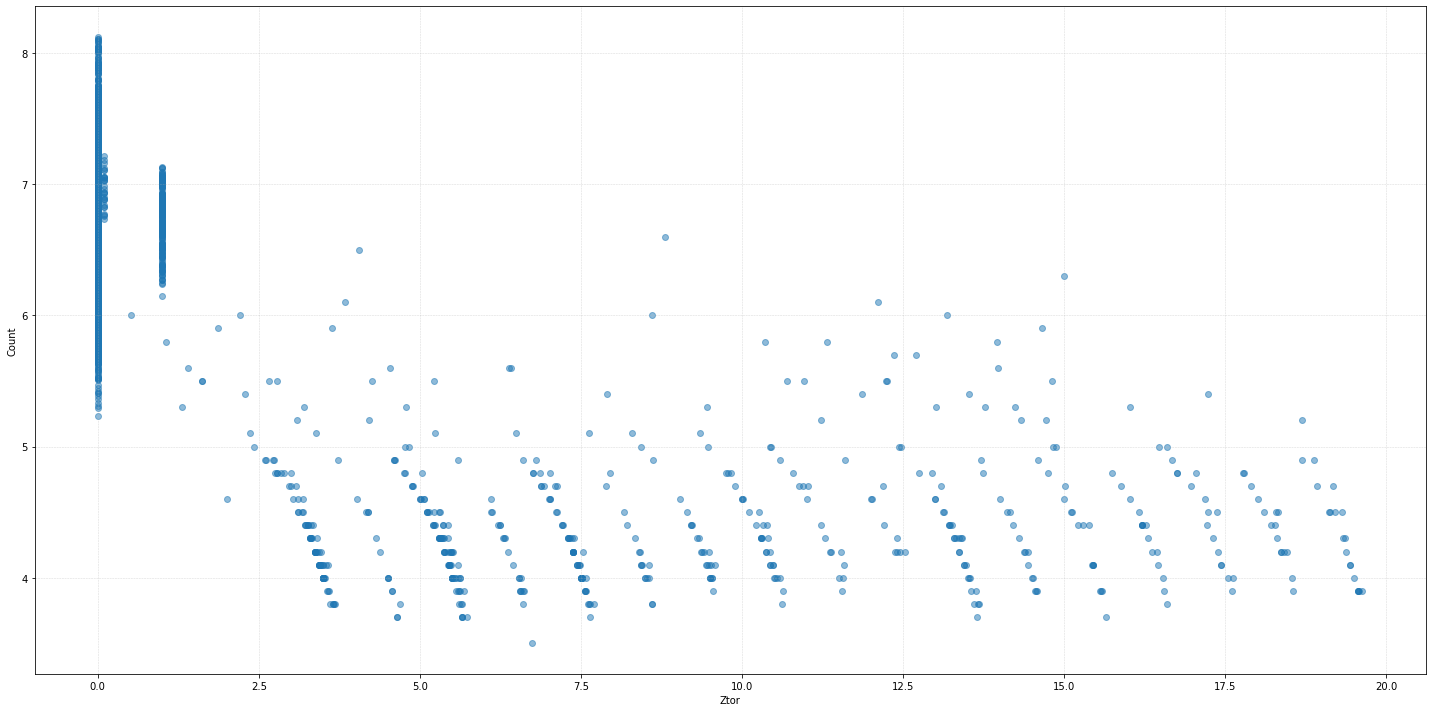

In [25]:
# Ztor vs mag
fig = plt.figure(figsize=(20, 10))

plt.scatter(rel_df.ztor, rel_df.mag, alpha=0.5)

plt.xlabel(f"Ztor")
plt.ylabel(f"Count")
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
plt.tight_layout()

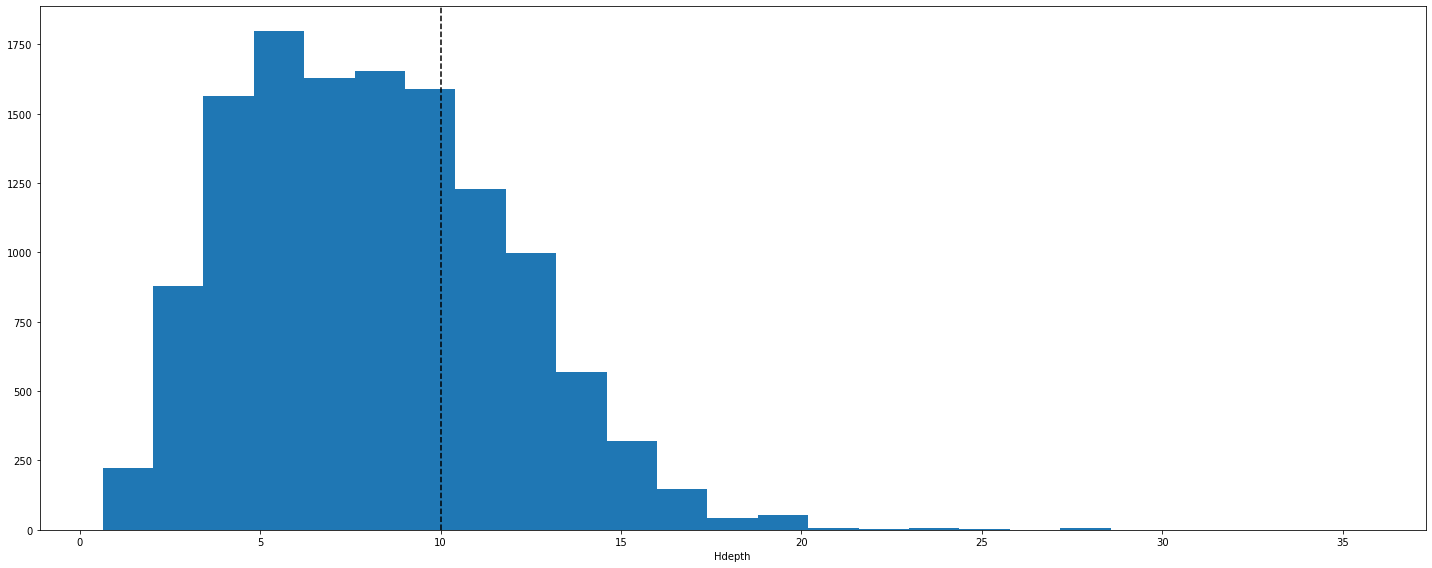

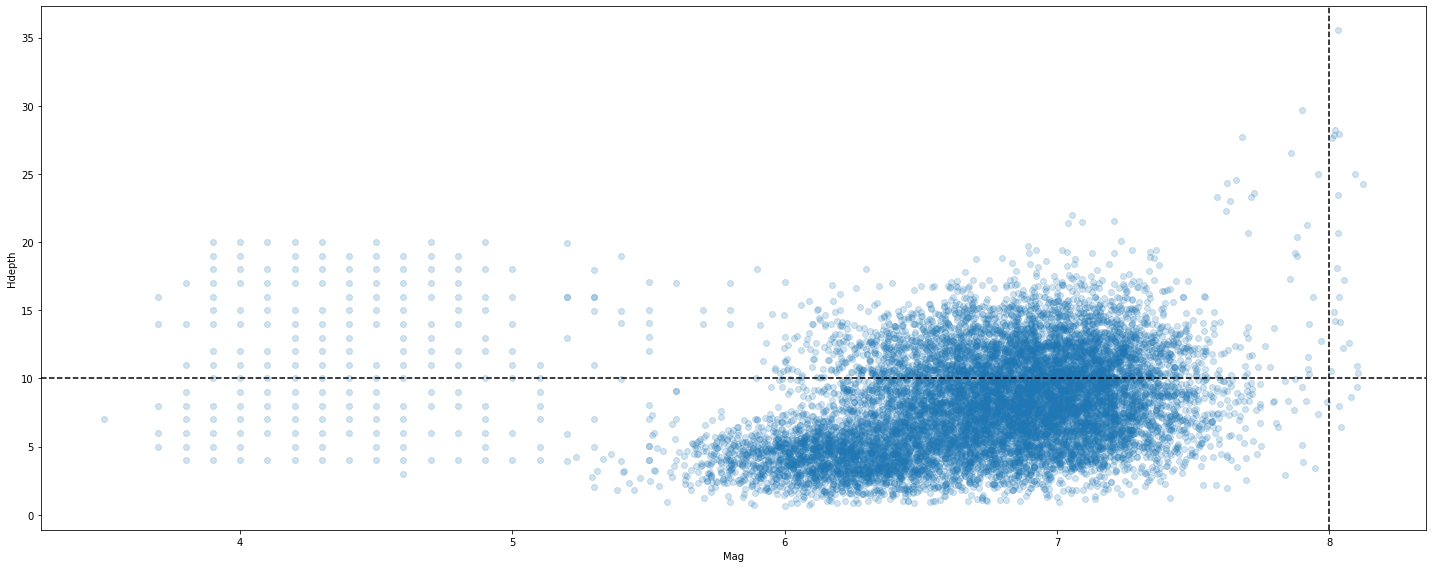

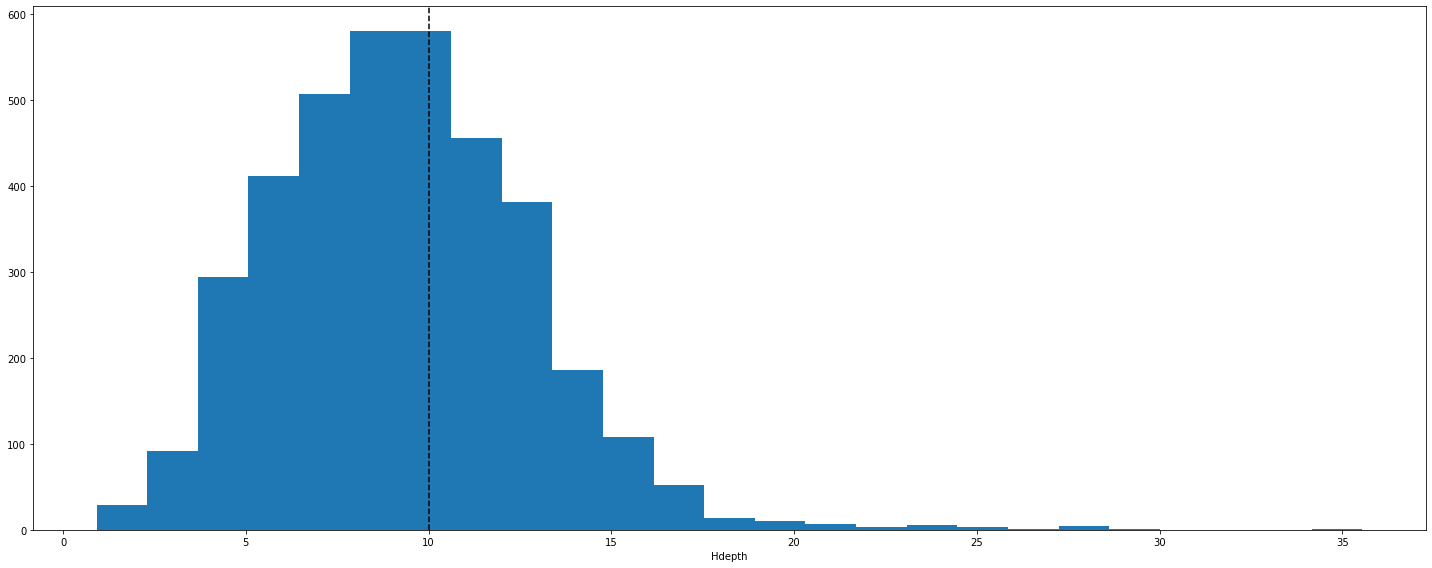

In [27]:
# Hdepth
hdepth = 10.0

fig = plt.figure(figsize=(20, 8))
plt.hist(rel_df["hdepth"], bins=25);
plt.axvline(hdepth, c="k", linestyle="--")
plt.xlabel("Hdepth")

fig.tight_layout()



fig = plt.figure(figsize=(20, 8))
t = rel_df.loc[:, ["mag", "hdepth"]].drop_duplicates()
plt.scatter(t.mag, t.hdepth, alpha=0.2)
plt.axvline(mag, c="k", linestyle="--")
plt.xlabel("Mag")
plt.ylabel("Hdepth")
plt.axhline(hdepth, linestyle="--", c="k")

fig.tight_layout()



fig = plt.figure(figsize=(20, 8))
plt.hist(t.loc[(t.mag > mag - 1.0) & (t.mag < mag + 1.0), "hdepth"], bins=25);
plt.axvline(hdepth, c="k", linestyle="--")
plt.xlabel("Hdepth")

fig.tight_layout()

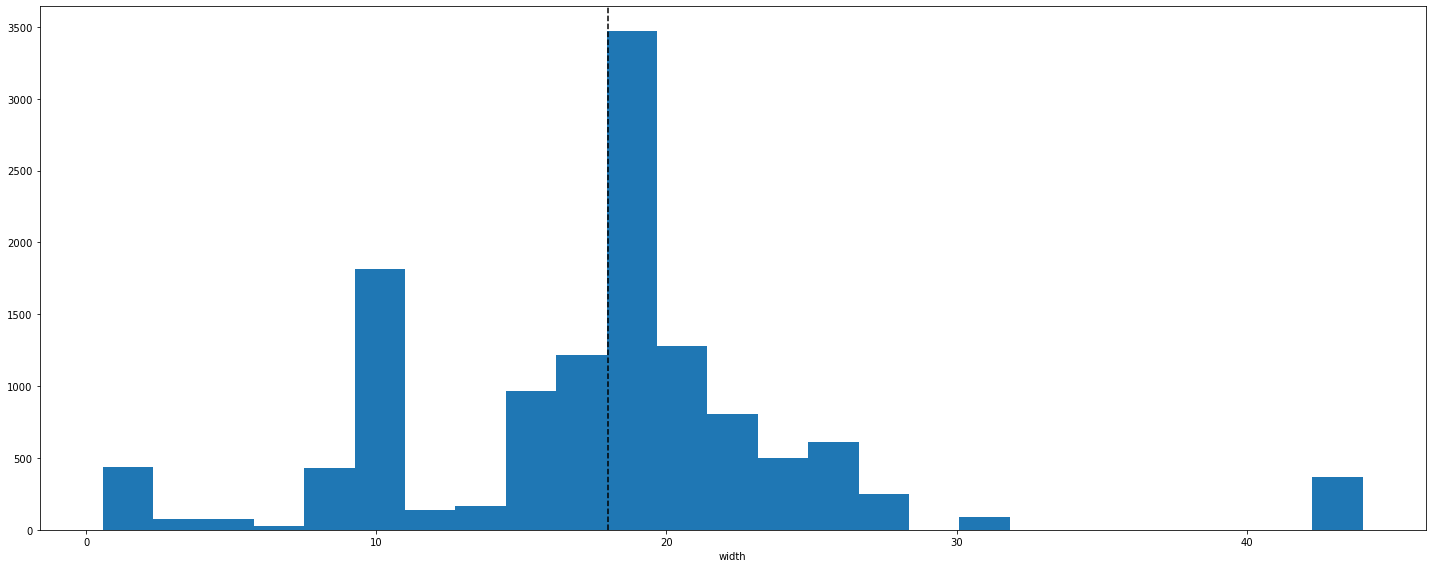

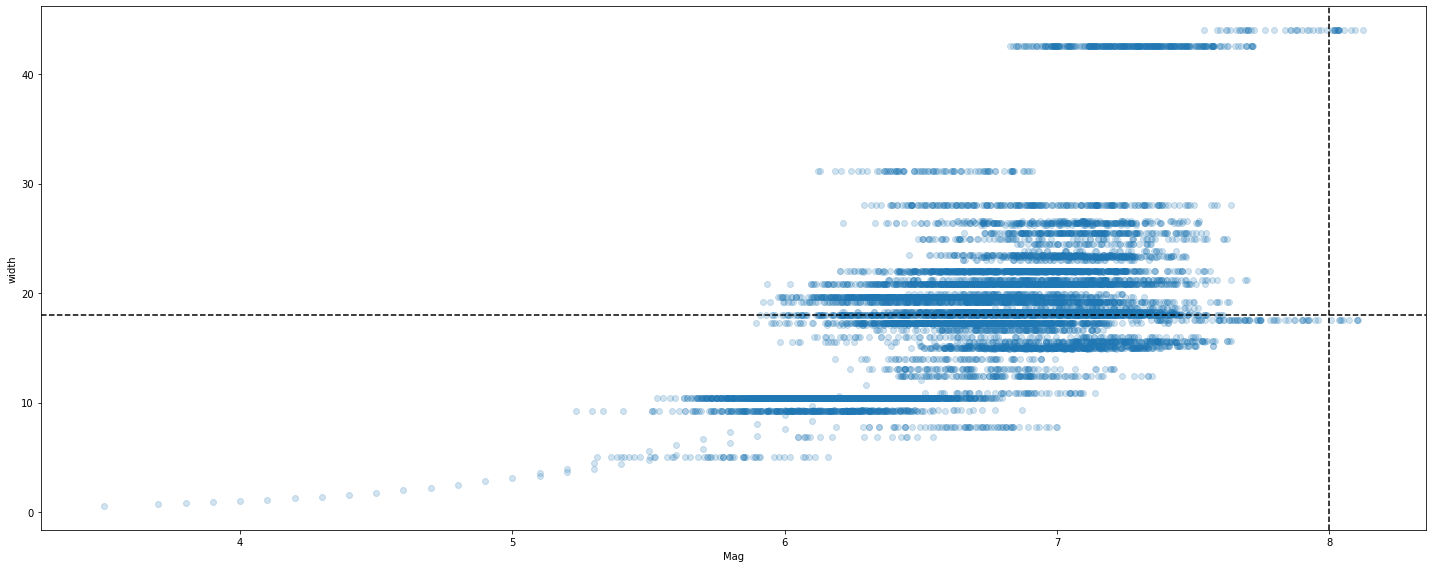

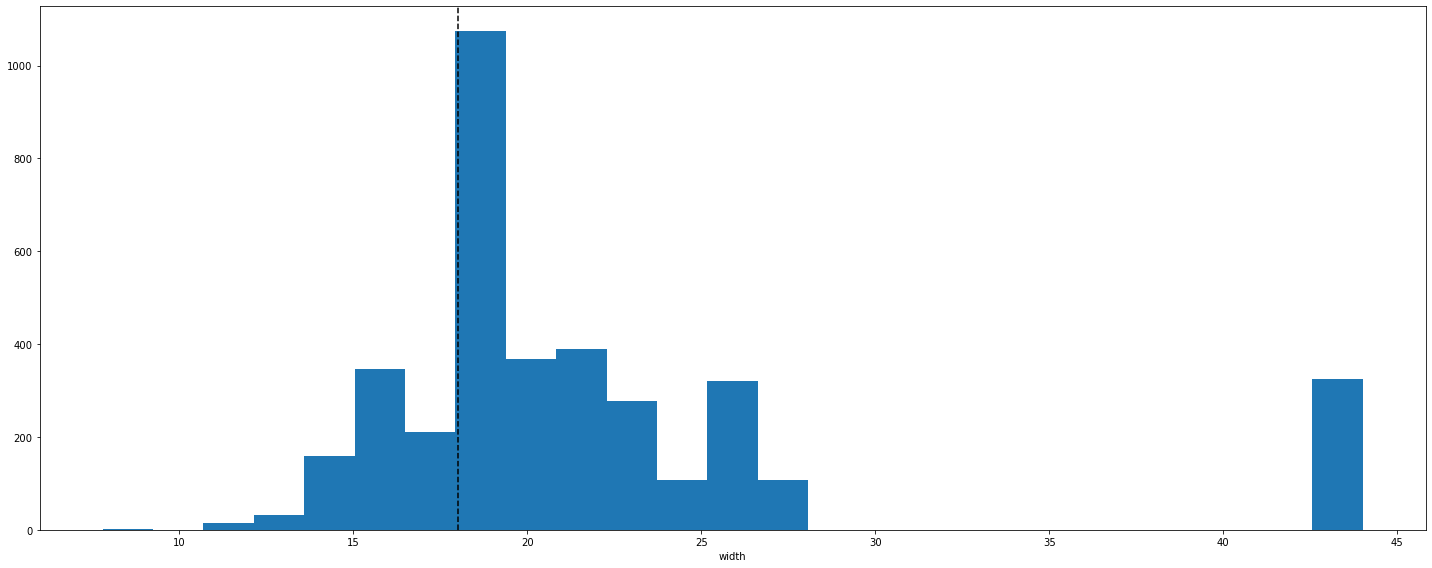

In [28]:
# Width
width = 18

fig = plt.figure(figsize=(20, 8))
plt.hist(rel_df["width"], bins=25);
plt.axvline(width, c="k", linestyle="--")
plt.xlabel("width")

fig.tight_layout()


fig = plt.figure(figsize=(20, 8))
t = rel_df.loc[:, ["mag", "width"]].drop_duplicates()
plt.scatter(t.mag, t.width, alpha=0.2)
plt.axvline(mag, c="k", linestyle="--")
plt.xlabel("Mag")
plt.ylabel("width")

plt.axhline(width, linestyle="--", c="k")

fig.tight_layout()


fig = plt.figure(figsize=(20, 8))
plt.hist(t.loc[(t.mag > mag - 1.0) & (t.mag < mag + 1.0), "width"], bins=25);
plt.axvline(width, c="k", linestyle="--")
plt.xlabel("width")

fig.tight_layout()

In [ ]:
fig = plt.figure(figsize=(20, 8))
t = rel_df.loc[:, ["mag", "is_point_source"]].drop_duplicates()
plt.scatter(t.mag, t.is_point_source, alpha=0.2)
plt.axvline(mag, c="k", linestyle="--")
plt.xlabel("Mag")
plt.ylabel("Is Point Source")

is_point_source = False

In [ ]:
print(f"Fault magnitude: {mag}")
print(f"Fault rake: {rake}")
print(f"Fault dip: {dip}")
print(f"Fault width: {width}")
print(f"Fault Ztor: {ztor}")
print(f"Fault Hdepth: {hdepth}")
print(f"Fault is point source: {is_point_source}")

## Site Parameters

- Vs30
- Vs500
- Z1.0
- Z2.5

See [link](https://quakecoresoft.canterbury.ac.nz/vs30/#) to assist in choosing these values

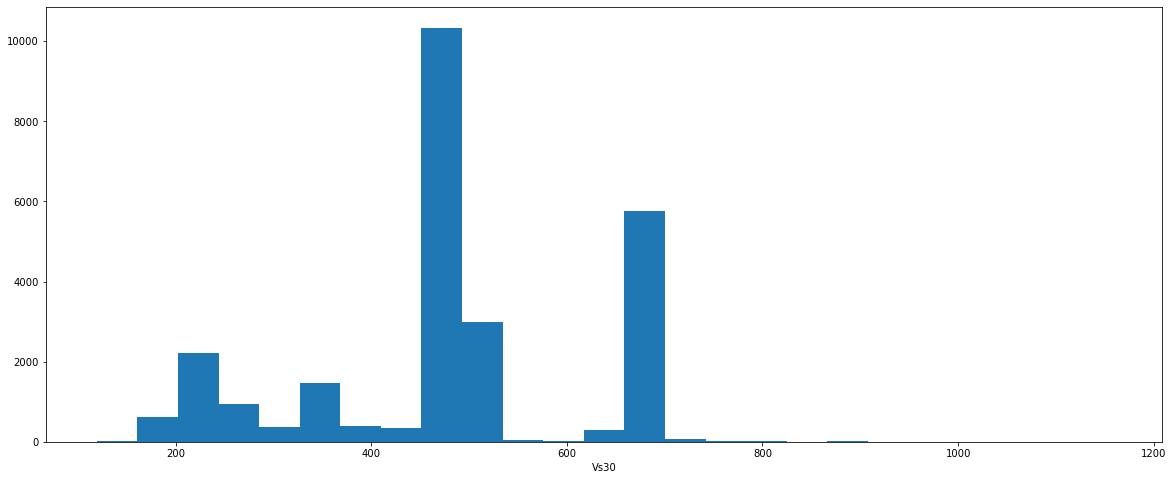

In [45]:
# vs30

fig = plt.figure(figsize=(20, 8))
plt.hist(site_df.vs30, bins=25);
plt.xlabel("Vs30")

vs30 = 800

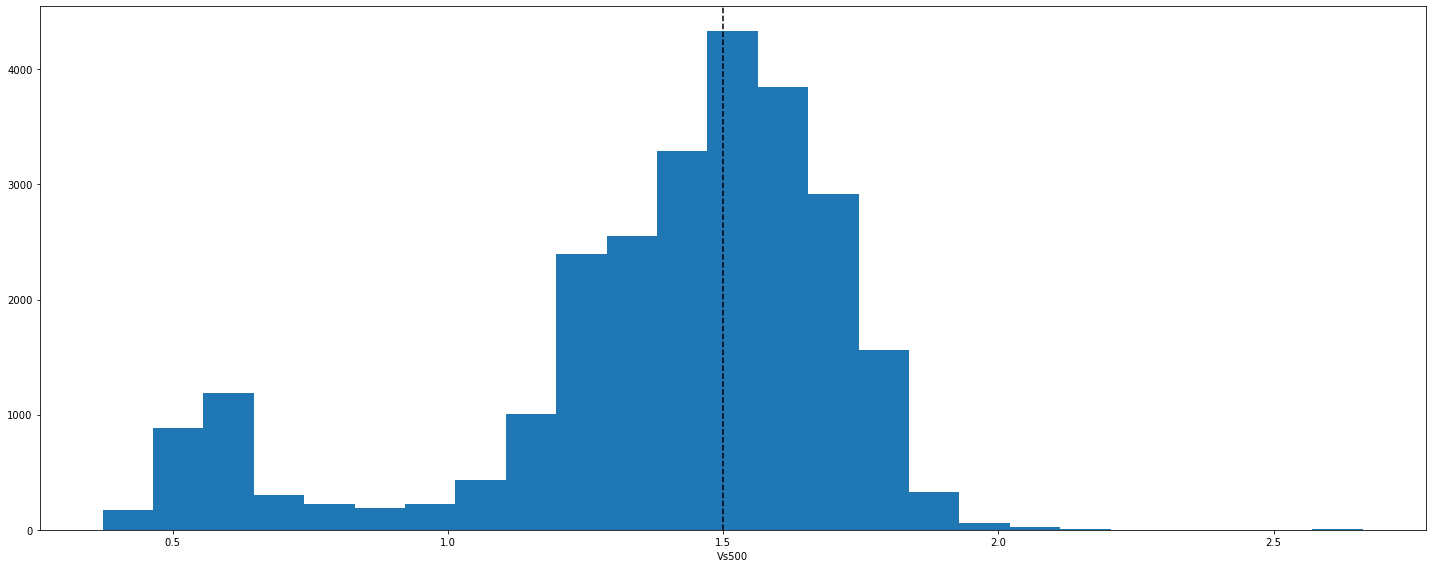

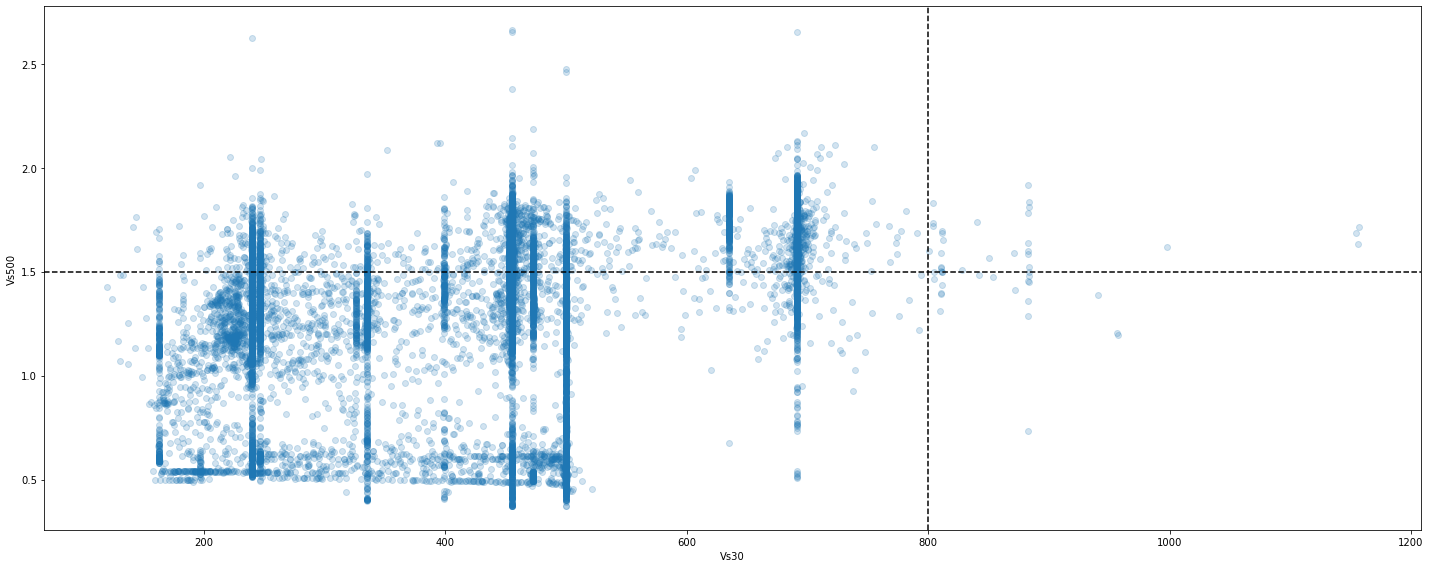

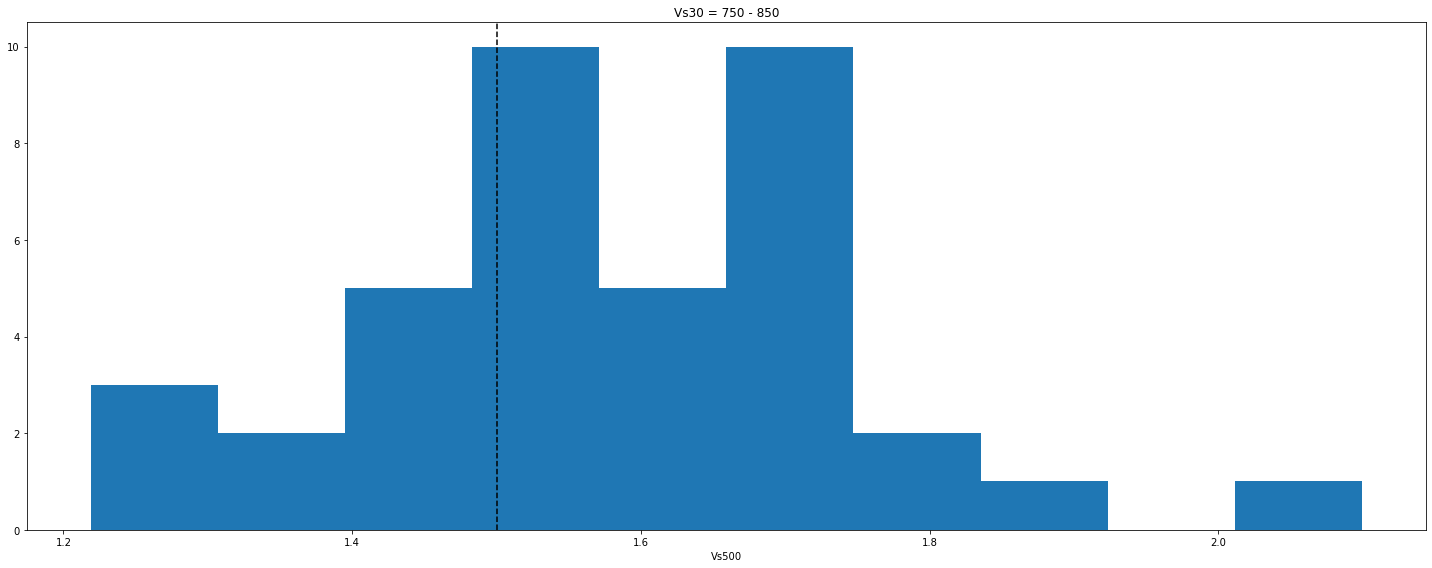

In [46]:
# vs500
vs500 = 1.5

fig = plt.figure(figsize=(20, 8))
plt.hist(site_df.vs500, bins=25);
plt.axvline(vs500, linestyle="--", c="k")
plt.xlabel("Vs500")
plt.tight_layout()


fig = plt.figure(figsize=(20, 8))
t = site_df.loc[:, ["vs30", "vs500"]].drop_duplicates()
plt.scatter(t.vs30, t.vs500, alpha=0.2)
plt.axvline(vs30, linestyle="--", c="k")
plt.axhline(vs500, linestyle="--", c="k")
plt.xlabel("Vs30")
plt.ylabel("Vs500")
plt.tight_layout()


fig = plt.figure(figsize=(20, 8))
plt.hist(t.loc[(t.vs30 > vs30 - 50) & (t.vs30 < vs30 + 50), "vs500"])
plt.axvline(vs500, linestyle="--", c="k")
plt.title(f"Vs30 = {vs30 - 50} - {vs30 + 50}")
plt.xlabel("Vs500")
plt.tight_layout()



Mean Z1.0: 0.12257025557996994
Median Z1.0: 0.12257025557996994


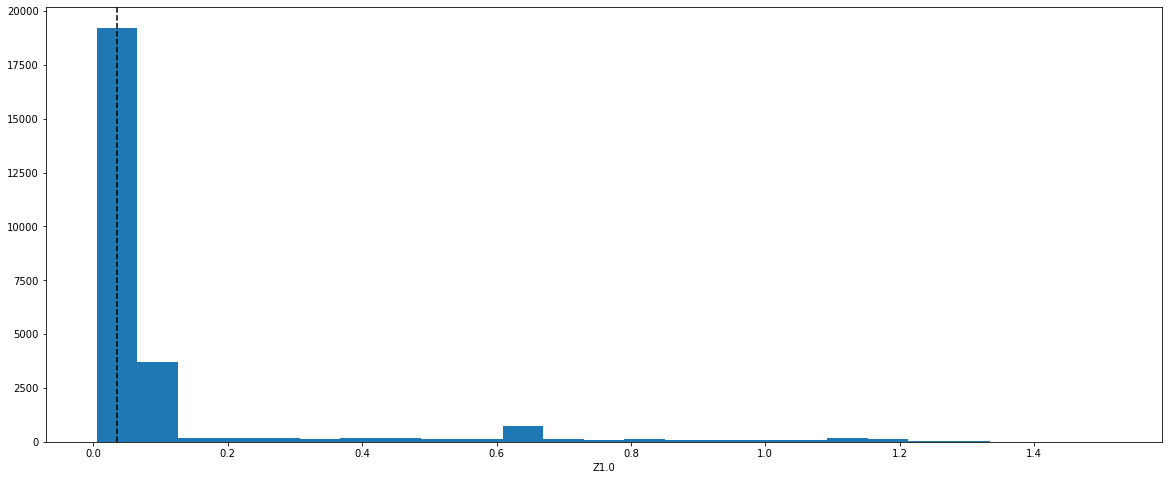

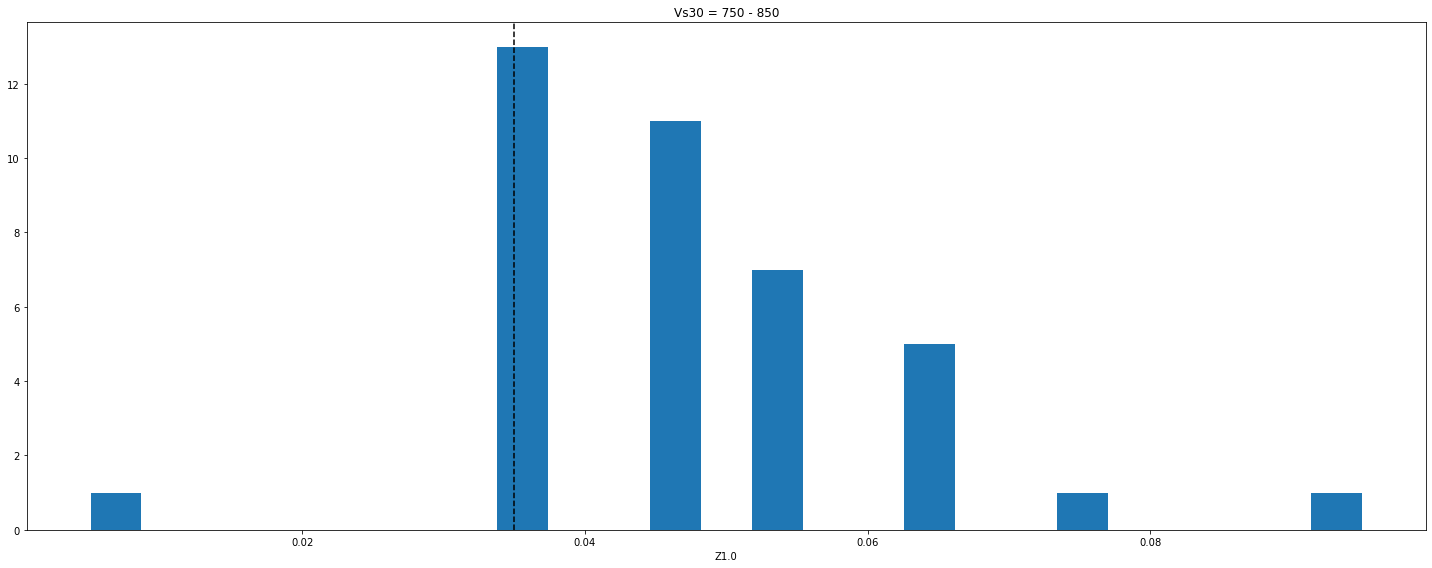

In [48]:
 # Z1.0
z1p0 = 0.035
    
    
fig = plt.figure(figsize=(20, 8))
plt.hist(site_df.z1p0, bins=25);
plt.axvline(z1p0, linestyle="--", c="k")
plt.xlabel("Z1.0")

fig = plt.figure(figsize=(20, 8))
t = site_df.loc[:, ["vs30", "z1p0"]].drop_duplicates()
plt.hist(t.loc[(t.vs30 > vs30 - 50) & (t.vs30 < vs30 + 50) & (t.z1p0 < 0.1), "z1p0"], bins=25)
plt.axvline(z1p0, linestyle="--", c="k")
plt.title(f"Vs30 = {vs30 - 50} - {vs30 + 50}")
plt.xlabel("Z1.0")
plt.tight_layout()


print(f"Mean Z1.0: {np.mean(site_df.z1p0)}")
print(f"Median Z1.0: {np.mean(site_df.z1p0)}")



Mean Z2.5: 0.8225290081338421
Median Z2.5: 0.8225290081338421


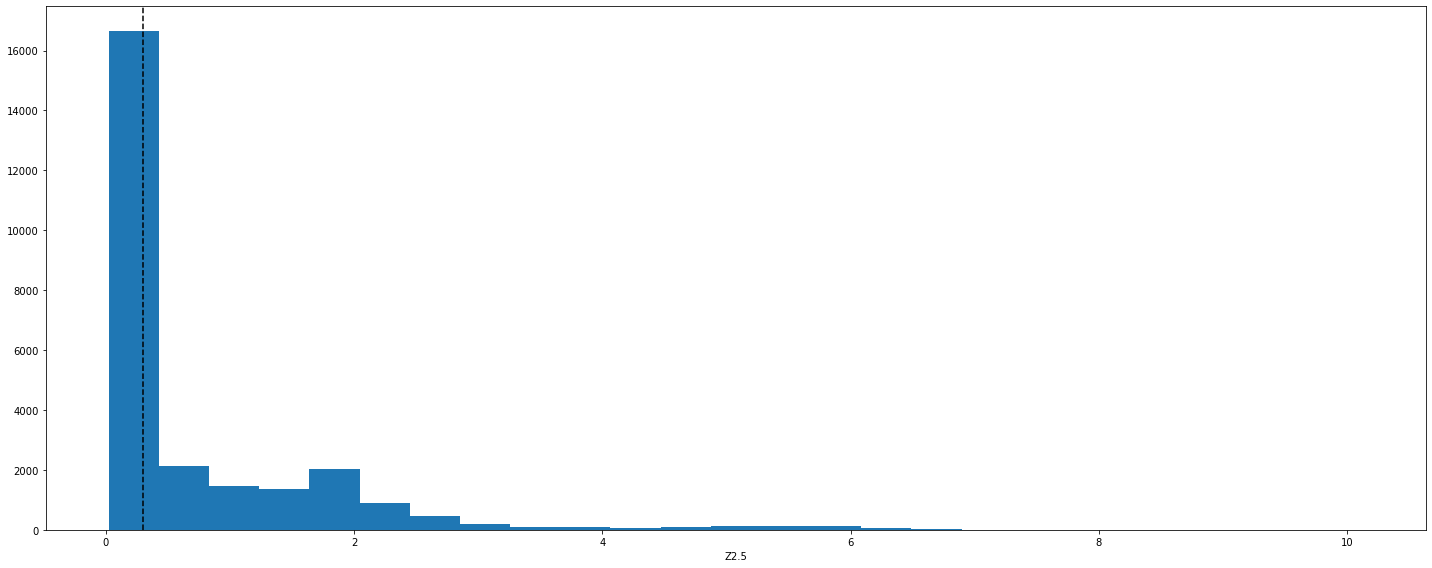

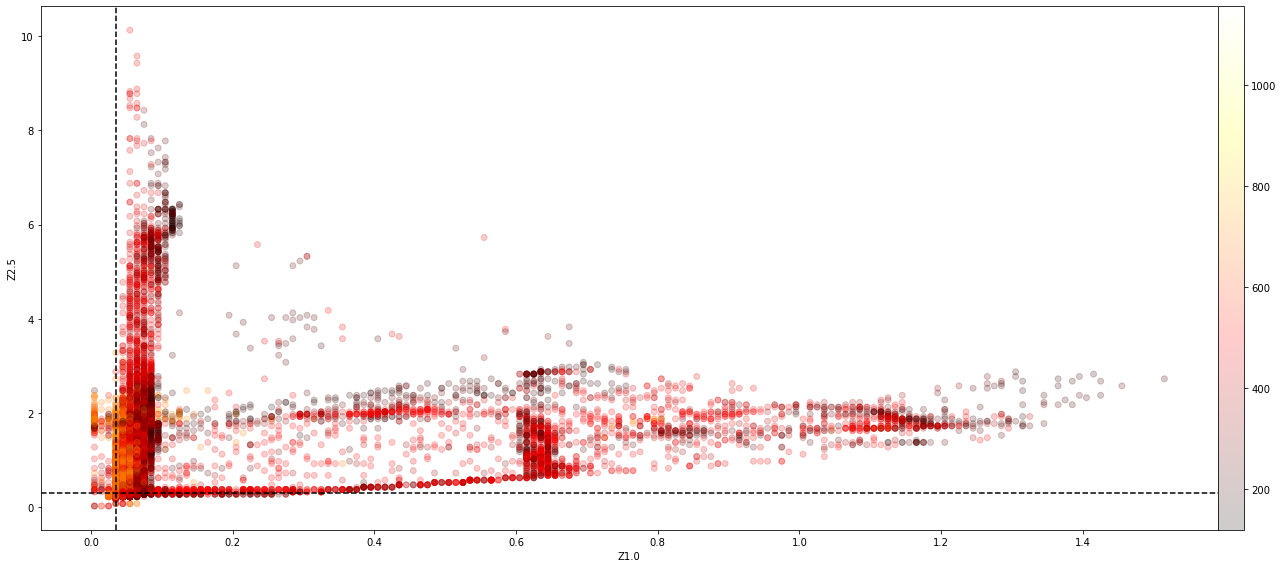

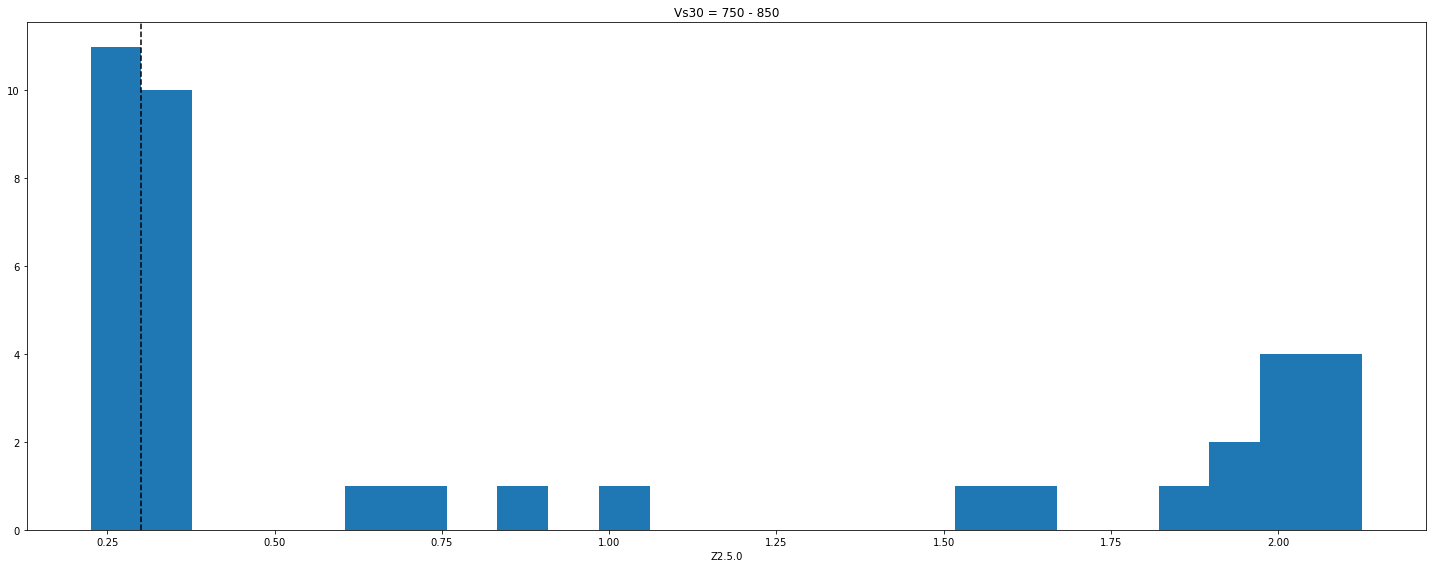

In [51]:
# Z2.5
z2p5 = 0.3



fig = plt.figure(figsize=(20, 8))
plt.hist(site_df.z2p5, bins=25);
plt.axvline(z2p5, linestyle="--", c="k")
plt.xlabel("Z2.5")
fig.tight_layout()

fig = plt.figure(figsize=(20, 8))
t = site_df.loc[:, ["z1p0", "z2p5", "vs30"]].drop_duplicates()
plt.scatter(t.z1p0, t.z2p5, alpha=0.2, c=t.vs30, cmap="hot")
plt.colorbar(pad=0)
plt.axvline(z1p0, linestyle="--", c="k")
plt.axhline(z2p5, linestyle="--", c="k")
plt.xlabel("Z1.0")
plt.ylabel("Z2.5")
fig.tight_layout()

# plt.ylim(0.0, 4.0)
# plt.xlim(0.0, 0.4)

fig = plt.figure(figsize=(20, 8))
t = site_df.loc[:, ["vs30", "z2p5"]].drop_duplicates()
plt.hist(t.loc[(t.vs30 > vs30 - 50) & (t.vs30 < vs30 + 50) & (t.z2p5 < 2.5), "z2p5"], bins=25)
plt.axvline(z2p5, linestyle="--", c="k")
plt.title(f"Vs30 = {vs30 - 50} - {vs30 + 50}")
plt.xlabel("Z2.5.0")
plt.tight_layout()



print(f"Mean Z2.5: {np.mean(site_df.z2p5)}")
print(f"Median Z2.5: {np.mean(site_df.z2p5)}")


In [43]:
print(f"Site Vs30: {vs30}")
print(f"Site Vs500: {vs500}")
print(f"Site Z1.0: {z1p0}")
print(f"Site Z2.5: {z2p5}")

Site Vs30: 250
Site Vs500: 1.5
Site Z1.0: 0.065
Site Z2.5: 0.3


## Site-Source Parameters

- Rrup
- Rjb
- Rx (GC1)
- Ry (GC1)

In [93]:
rrup = 75

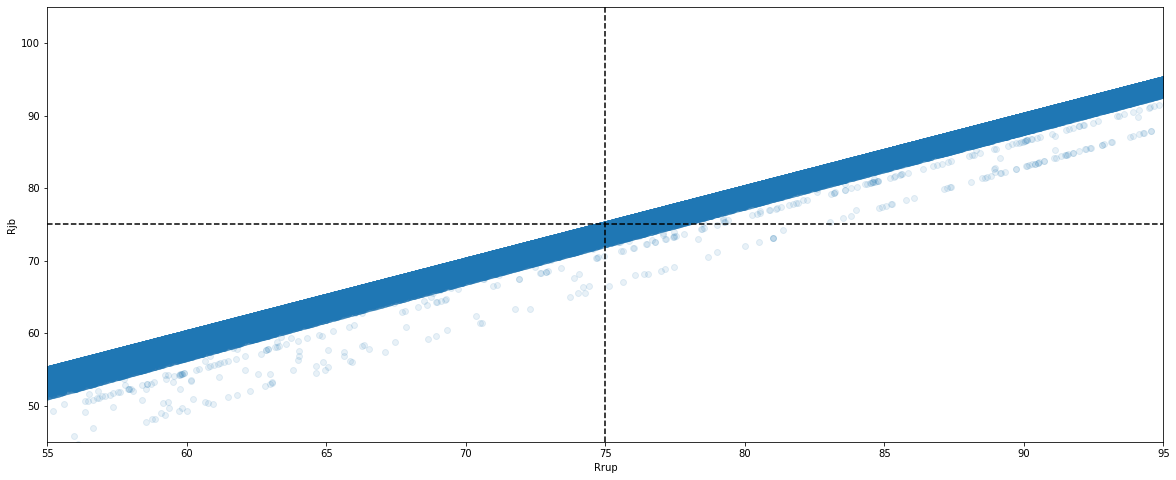

In [98]:
# Rjb
fig = plt.figure(figsize=(20, 8))
t = distance_df.loc[:, ["rrup", "rjb"]].drop_duplicates()
plt.scatter(t.rrup.values[::5], t.rjb.values[::5], alpha=0.1)
plt.axvline(rrup, linestyle="--", c="k")

plt.xlim(rrup - 20, rrup + 20)
plt.ylim(rrup - 30, rrup + 30)

plt.xlabel("Rrup")
plt.ylabel("Rjb")

rjb = 75
plt.axhline(rjb, linestyle="--", c="k")

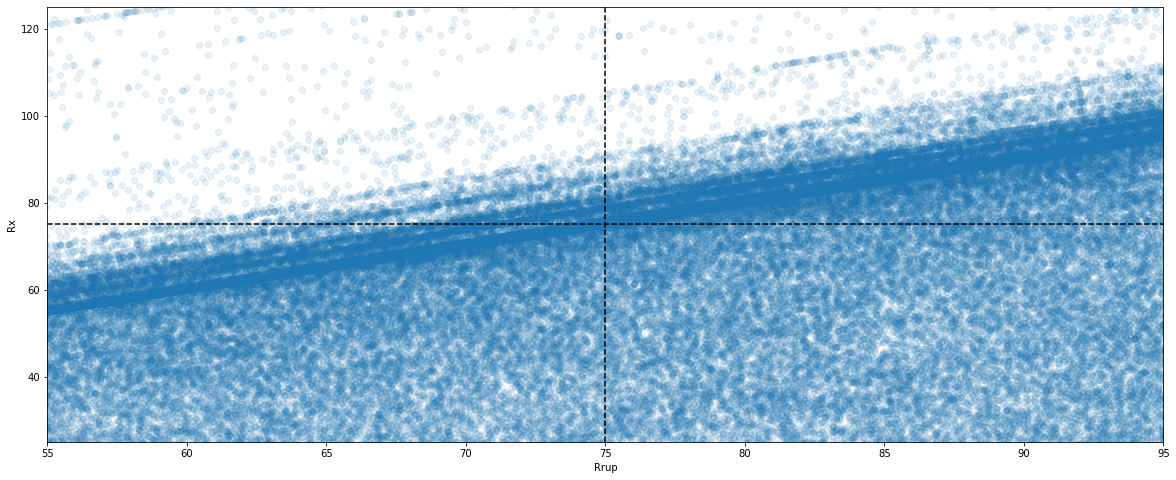

In [95]:
# Rx
fig = plt.figure(figsize=(20, 8))
t = distance_df.loc[:, ["rrup", "rx"]].drop_duplicates()
plt.scatter(t.rrup.values[::3], t.rx.values[::3], alpha=0.1)
plt.axvline(rrup, linestyle="--", c="k")

plt.xlim(rrup - 20, rrup + 20)
plt.ylim(rrup - 50, rrup + 50)

plt.xlabel("Rrup")
plt.ylabel("Rx")

rx = 75
plt.axhline(rx, linestyle="--", c="k")

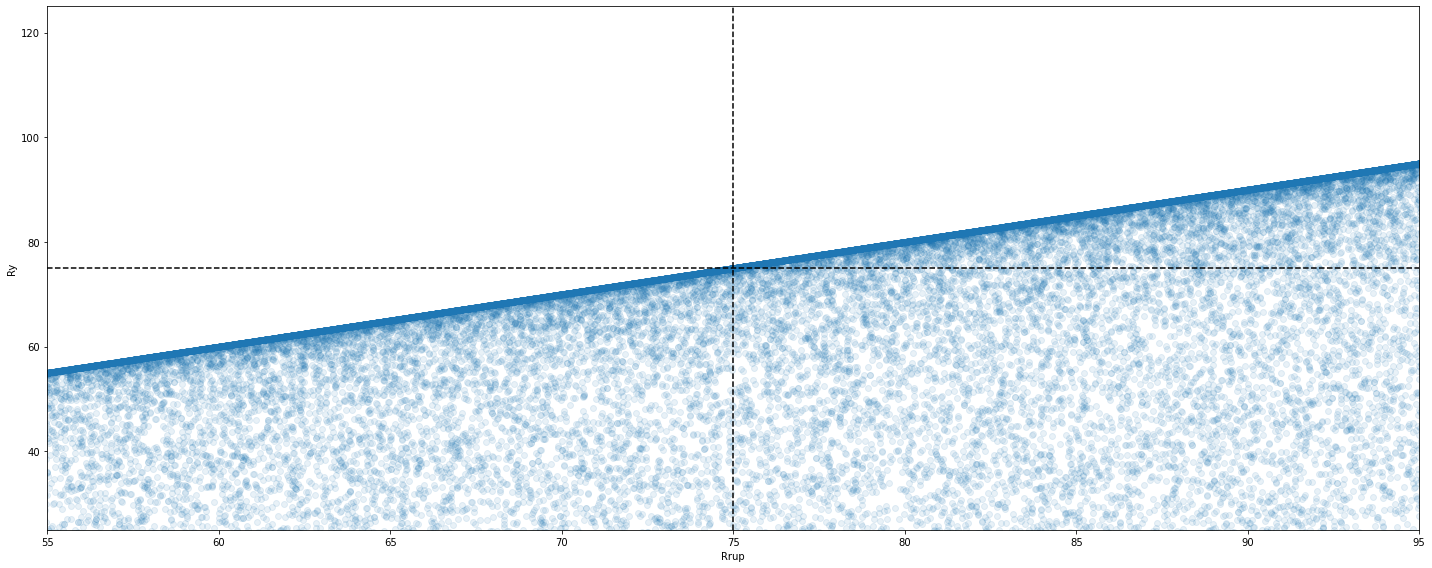

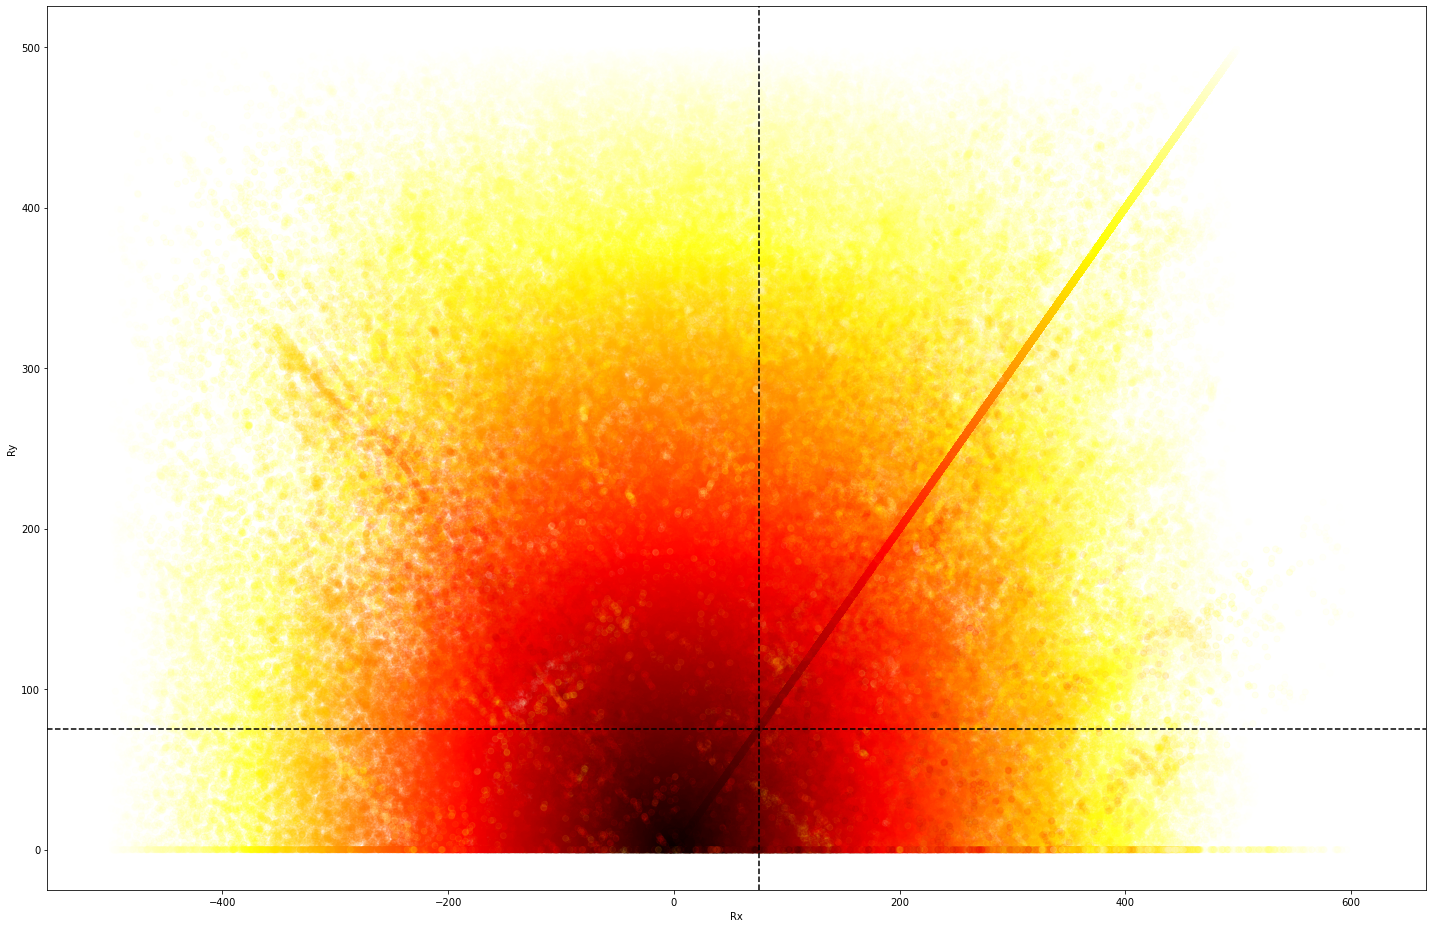

In [96]:
# Ry
fig = plt.figure(figsize=(20, 8))
t = distance_df.loc[:, ["rrup", "ry"]].drop_duplicates()
plt.scatter(t.rrup.values[::20], t.ry.values[::20], alpha=0.1)
plt.axvline(rrup, linestyle="--", c="k")

plt.xlim(rrup - 20, rrup + 20)
plt.ylim(rrup - 50, rrup + 50)

plt.xlabel("Rrup")
plt.ylabel("Ry")

ry = 75
plt.axhline(ry, linestyle="--", c="k")
fig.tight_layout()



fig = plt.figure(figsize=(20, 13))

t = distance_df.loc[:, ["rx", "ry", "rrup"]].drop_duplicates()
plt.scatter(t.rx.values[::20], t.ry.values[::20], alpha=0.1, c=t.rrup.values[::20], cmap="hot")
plt.axvline(rx, linestyle="--", c="k")
plt.axhline(ry, linestyle="--", c="k")

plt.xlabel("Rx")
plt.ylabel("Ry")

fig.tight_layout()

In [99]:
print(f"Site-Source Rrup: {rrup}")
print(f"Site-Source Rjb: {rjb}")
print(f"Site-Source Rx: {rx}")
print(f"Site-Source Ry: {ry}")

Site-Source Rrup: 75
Site-Source Rjb: 75
Site-Source Rx: 75
Site-Source Ry: 75
